# PINN Helmholtz — Multi-K Sweep
## Comparing PINN performance for K = 1, 3, 5, 10, 20

This notebook runs the full PINN pipeline (Adam → L-BFGS) for each value of the
Helmholtz wave number K, collects quantitative metrics, and produces a comparative
analysis with publication-quality plots.

**Manufactured solution (same for all K):**
```
u*(x,y) = sin(πx) sin(πy)
f(x,y)  = (k² − 2π²) sin(πx) sin(πy)
```

The exact solution does **not** change with K — only the forcing term and the PDE
difficulty change. Higher K means stronger reactive term and a harder optimisation
landscape for the PINN.

---

In [1]:
# ── Cell 1: Imports & Fixed Hyperparameters ───────────────────────────────────

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from torch.optim import Adam, LBFGS
from torch.optim.lr_scheduler import CosineAnnealingLR
from scipy.stats import qmc
import time
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ───────────────────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)

# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device : {device}")
if device.type == 'cuda':
    print(f"GPU          : {torch.cuda.get_device_name(0)}")

# ── Fixed hyperparameters (shared across all K values) ───────────────────────
N_INT     = 10000   # Interior collocation points (LHS)
N_BC      = 200     # Boundary points per edge
HIDDEN    = 128     # Neurons per hidden layer
N_LAYERS  = 6       # Hidden layers
N_FOURIER = 16      # Fourier feature frequencies
LR_ADAM   = 1e-3    # Initial Adam LR
N_ADAM    = 15000   # Adam iterations
N_LBFGS   = 8000    # Max L-BFGS iterations
GRAD_CLIP = 1.0     # Gradient clipping max norm

# ── K values to sweep ─────────────────────────────────────────────────────────
K_VALUES  = [1, 3, 5, 10, 20]

pi = torch.pi
print(f"\nWill sweep K = {K_VALUES}")
print(f"Total runs   : {len(K_VALUES)}")
print(f"Est. time    : ~{len(K_VALUES) * 8:.0f}–{len(K_VALUES) * 15:.0f} min on CPU  "
      f"(~{len(K_VALUES) * 2:.0f}–{len(K_VALUES) * 4:.0f} min on GPU)")

Using device : cuda
GPU          : Tesla T4

Will sweep K = [1, 3, 5, 10, 20]
Total runs   : 5
Est. time    : ~40–75 min on CPU  (~10–20 min on GPU)


In [2]:
# ── Cell 2: Analytical helpers ────────────────────────────────────────────────

def u_exact_np(x, y):
    """Ground-truth solution: u*(x,y) = sin(πx)sin(πy).  Independent of K."""
    return np.sin(np.pi * x) * np.sin(np.pi * y)

def f_forcing_np(x, y, k):
    """Forcing term for a given k."""
    return (k**2 - 2 * np.pi**2) * np.sin(np.pi * x) * np.sin(np.pi * y)

# ── Evaluation grid (built once, reused for every K) ─────────────────────────
N_eval = 200
x_e    = np.linspace(0, 1, N_eval)
y_e    = np.linspace(0, 1, N_eval)
XX, YY = np.meshgrid(x_e, y_e)
U_REF  = u_exact_np(XX, YY)   # same for all K

xy_eval_np = np.stack([XX.ravel(), YY.ravel()], axis=1)
xy_eval    = torch.tensor(xy_eval_np, dtype=torch.float32, device=device)

print(f"Evaluation grid : {N_eval}×{N_eval} = {N_eval**2:,} points")
print(f"u* range        : [{U_REF.min():.4f}, {U_REF.max():.4f}]")

Evaluation grid : 200×200 = 40,000 points
u* range        : [0.0000, 0.9999]


In [3]:
# ── Cell 3: Architecture — K-aware PINN ──────────────────────────────────────
#
# The only change from the original: K is passed as a constructor argument
# so each model instance is tied to a specific wave number. This is needed
# because K appears inside the residual() method.

class FourierEmbedding(nn.Module):
    def __init__(self, n_freqs: int = N_FOURIER, sigma: float = 1.0):
        super().__init__()
        B = torch.randn(2, n_freqs) * sigma
        self.register_buffer('B', B)
        self.out_dim = 4 * n_freqs

    def forward(self, xy):
        proj = 2 * pi * xy @ self.B
        return torch.cat([torch.sin(proj), torch.cos(proj),
                          torch.sin(2*proj), torch.cos(2*proj)], dim=-1)


class PINN(nn.Module):
    """
    K-aware PINN.  Identical to the original except K is stored as an
    instance attribute so multiple models with different K can coexist.
    """
    def __init__(self, k: float, hidden: int = HIDDEN,
                 n_layers: int = N_LAYERS, n_freqs: int = N_FOURIER):
        super().__init__()
        self.k     = k
        self.embed = FourierEmbedding(n_freqs)
        in_dim     = self.embed.out_dim

        layers = [nn.Linear(in_dim, hidden), nn.Tanh()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers += [nn.Linear(hidden, 1)]
        self.net = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, xy):
        x    = xy[:, 0:1]
        y    = xy[:, 1:2]
        mask = x * (1 - x) * y * (1 - y)
        return mask * self.net(self.embed(xy))

    def residual(self, xy):
        k   = self.k
        xy_ = xy.clone().requires_grad_(True)
        u   = self.forward(xy_)

        g   = torch.autograd.grad(u, xy_,
                                  grad_outputs=torch.ones_like(u),
                                  create_graph=True, retain_graph=True)[0]
        u_x = g[:, 0:1]
        u_y = g[:, 1:2]

        u_xx = torch.autograd.grad(u_x, xy_,
                                   grad_outputs=torch.ones_like(u_x),
                                   create_graph=True)[0][:, 0:1]
        u_yy = torch.autograd.grad(u_y, xy_,
                                   grad_outputs=torch.ones_like(u_y),
                                   create_graph=True)[0][:, 1:2]

        xc = xy_[:, 0:1]
        yc = xy_[:, 1:2]
        f  = (k**2 - 2*pi**2) * torch.sin(pi*xc) * torch.sin(pi*yc)
        return u_xx + u_yy + k**2 * u - f


print("PINN class defined (K-aware).")
print(f"Parameters per model: {sum(p.numel() for p in PINN(k=1.0).parameters()):,}")

PINN class defined (K-aware).
Parameters per model: 91,009


In [4]:
# ── Cell 4: Sampling helpers ──────────────────────────────────────────────────

def sample_interior_lhs(N):
    sampler = qmc.LatinHypercube(d=2, seed=42)
    pts     = 0.001 + 0.998 * sampler.random(n=N)
    return torch.tensor(pts, dtype=torch.float32, device=device)

# Collocation points are the same for every K
xy_int = sample_interior_lhs(N_INT)
print(f"Interior LHS points : {xy_int.shape}")

# ── Error metric helpers ──────────────────────────────────────────────────────

def relative_L2(pred, ref):
    return np.sqrt(np.mean((pred - ref)**2)) / (np.sqrt(np.mean(ref**2)) + 1e-15)

def max_error(pred, ref):
    return np.max(np.abs(pred - ref))

def rmse(pred, ref):
    return np.sqrt(np.mean((pred - ref)**2))

Interior LHS points : torch.Size([10000, 2])


In [5]:
# ── Cell 5: Training function — runs one full Adam → L-BFGS sweep for a given K

def train_one_k(k_val, verbose=True):
    """
    Full two-stage training for a single K value.
    Returns a dict with model, histories, metrics, and timing.
    """
    sep = "═" * 65
    if verbose:
        print(f"\n{sep}")
        print(f"  TRAINING  K = {k_val}")
        print(sep)

    torch.manual_seed(42)   # same init for fair comparison
    model = PINN(k=k_val).to(device)

    def compute_loss(m):
        r = m.residual(xy_int)
        loss_pde = torch.mean(r**2)
        return loss_pde, loss_pde, loss_pde

    # ── Stage 1: Adam ────────────────────────────────────────────────────────
    opt       = Adam(model.parameters(), lr=LR_ADAM)
    scheduler = CosineAnnealingLR(opt, T_max=N_ADAM, eta_min=1e-5)
    history   = {'total': [], 'pde': []}
    best_adam = {'loss': float('inf'), 'state': None, 'epoch': 0}
    ckpt_path = f'best_K{k_val}.pth'

    if verbose:
        print(f"  Stage 1 — Adam ({N_ADAM} iters)")
        print(f"  {'Iter':>6}  {'Loss':>12}  {'LR':>10}")

    t0 = time.time()
    for epoch in range(N_ADAM):
        opt.zero_grad()
        loss_pde, _, loss = compute_loss(model)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        opt.step()
        scheduler.step()

        lv = loss.item()
        history['total'].append(lv)
        history['pde'].append(loss_pde.item())

        if lv < best_adam['loss']:
            best_adam['loss']  = lv
            best_adam['epoch'] = epoch
            best_adam['state'] = {k: v.clone() for k, v in model.state_dict().items()}
            torch.save({'model_state': best_adam['state'], 'epoch': epoch,
                        'loss': lv}, ckpt_path)

        if verbose and (epoch % 3000 == 0 or epoch == N_ADAM - 1):
            print(f"  {epoch:>6d}  {lv:>12.4e}  "
                  f"{scheduler.get_last_lr()[0]:>10.2e}")

    adam_time = time.time() - t0
    if verbose:
        print(f"  Adam done in {adam_time:.1f}s  |  "
              f"best = {best_adam['loss']:.4e} @ ep {best_adam['epoch']}")

    # ── Stage 2: L-BFGS ──────────────────────────────────────────────────────
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt['model_state'])

    opt_lb = LBFGS(model.parameters(), max_iter=N_LBFGS,
                   tolerance_grad=1e-11, tolerance_change=1e-13,
                   history_size=100, line_search_fn='strong_wolfe')

    lbfgs_hist = []
    best_lb    = {'loss': float('inf'), 'state': None}
    counter    = [0]

    def closure():
        opt_lb.zero_grad()
        loss_pde, _, loss = compute_loss(model)
        loss.backward()
        lv = loss.item()
        lbfgs_hist.append(lv)
        if lv < best_lb['loss']:
            best_lb['loss']  = lv
            best_lb['state'] = {k: v.clone() for k, v in model.state_dict().items()}
        counter[0] += 1
        if verbose and counter[0] % 1000 == 0:
            print(f"  L-BFGS [{counter[0]:4d}]  loss = {lv:.4e}")
        return loss

    if verbose:
        print(f"  Stage 2 — L-BFGS (max {N_LBFGS} iters)")
    t1 = time.time()
    opt_lb.step(closure)
    lbfgs_time = time.time() - t1

    model.load_state_dict(best_lb['state'])
    if verbose:
        print(f"  L-BFGS done in {lbfgs_time:.1f}s  |  "
              f"best = {best_lb['loss']:.4e}  ({counter[0]} calls)")

    # ── Evaluate ─────────────────────────────────────────────────────────────
    model.eval()
    with torch.no_grad():
        U_pred = model(xy_eval).cpu().numpy().reshape(N_eval, N_eval)

    E_abs  = np.abs(U_pred - U_REF)
    rel_l2 = relative_L2(U_pred, U_REF)
    l_inf  = max_error(U_pred, U_REF)
    rmse_v = rmse(U_pred, U_REF)
    f_vals = f_forcing_np(XX, YY, k=k_val)

    if verbose:
        print(f"\n  ── Metrics for K = {k_val} ──")
        print(f"  Relative L2 : {rel_l2:.4e}")
        print(f"  L∞ error    : {l_inf:.4e}")
        print(f"  RMSE        : {rmse_v:.4e}")
        print(f"  f range     : [{f_vals.min():.3f}, {f_vals.max():.3f}]")
        print(f"  Total time  : {adam_time + lbfgs_time:.1f}s")

    return {
        'k'           : k_val,
        'model'       : model,
        'adam_hist'   : history,
        'lbfgs_hist'  : lbfgs_hist,
        'U_pred'      : U_pred,
        'E_abs'       : E_abs,
        'f_vals'      : f_vals,
        'rel_l2'      : rel_l2,
        'l_inf'       : l_inf,
        'rmse'        : rmse_v,
        'best_adam'   : best_adam['loss'],
        'best_lbfgs'  : best_lb['loss'],
        'adam_time'   : adam_time,
        'lbfgs_time'  : lbfgs_time,
        'total_time'  : adam_time + lbfgs_time,
    }

print("train_one_k() defined and ready.")

train_one_k() defined and ready.


In [6]:
# ── Cell 6: RUN THE SWEEP ─────────────────────────────────────────────────────
#
# This is the main compute cell. On a GPU P100 it takes ~10–25 min total.
# On CPU expect ~40–80 min. Results are stored in `results` dict keyed by K.

results = {}  # k_val -> result dict from train_one_k

sweep_start = time.time()

for k_val in K_VALUES:
    results[k_val] = train_one_k(k_val, verbose=True)

total_sweep = time.time() - sweep_start
print(f"\n{'='*65}")
print(f"  SWEEP COMPLETE — total wall time: {total_sweep/60:.1f} min")
print(f"{'='*65}")

# ── Quick summary table ───────────────────────────────────────────────────────
print(f"\n{'K':>4}  {'Rel L2':>10}  {'L∞':>10}  {'RMSE':>10}  "
      f"{'Best LBFGS':>12}  {'Time(s)':>8}")
print("-" * 62)
for k_val in K_VALUES:
    r = results[k_val]
    print(f"{k_val:>4}  {r['rel_l2']:>10.4e}  {r['l_inf']:>10.4e}  "
          f"{r['rmse']:>10.4e}  {r['best_lbfgs']:>12.4e}  {r['total_time']:>8.1f}")


═════════════════════════════════════════════════════════════════
  TRAINING  K = 1
═════════════════════════════════════════════════════════════════
  Stage 1 — Adam (15000 iters)
    Iter          Loss          LR
       0    1.2605e+02    1.00e-03
    3000    1.8014e-03    9.05e-04
    6000    8.7061e-05    6.58e-04
    9000    8.5290e-05    3.52e-04
   12000    5.6342e-06    1.04e-04
   14999    4.6034e-06    1.00e-05
  Adam done in 522.1s  |  best = 4.6034e-06 @ ep 14999
  Stage 2 — L-BFGS (max 8000 iters)
  L-BFGS [1000]  loss = 8.3150e-07
  L-BFGS [2000]  loss = 3.5939e-07
  L-BFGS done in 92.4s  |  best = 3.5903e-07  (2011 calls)

  ── Metrics for K = 1 ──
  Relative L2 : 9.4068e-07
  L∞ error    : 1.4207e-06
  RMSE        : 4.6799e-07
  f range     : [-18.738, -0.000]
  Total time  : 614.5s

═════════════════════════════════════════════════════════════════
  TRAINING  K = 3
═════════════════════════════════════════════════════════════════
  Stage 1 — Adam (15000 iters)
    It

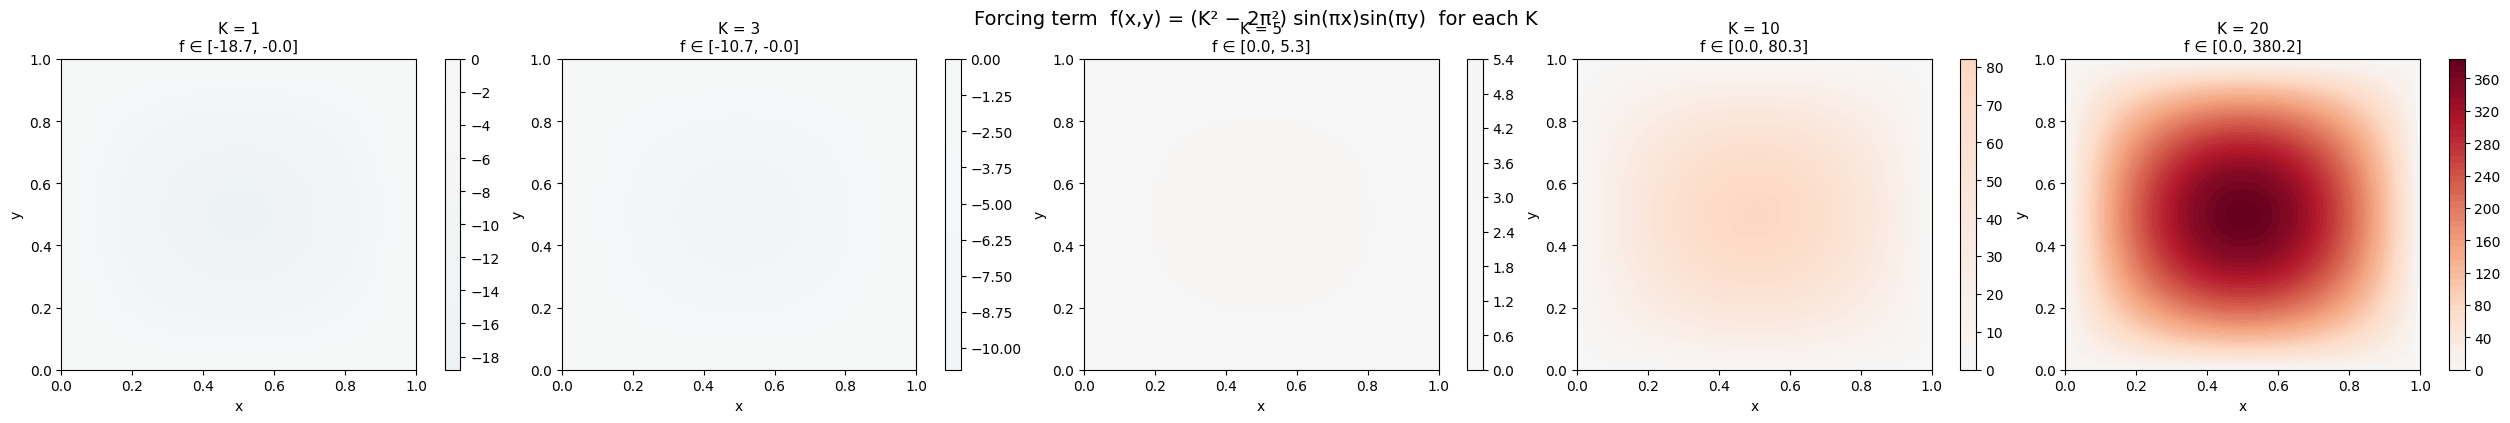

Note: sign flips at K = π√2 ≈ 4.44 — forcing changes from "suction" to "source".


In [7]:
# ── Cell 7: Plot 1 — Forcing term evolution across K ─────────────────────────
#
# Shows how f(x,y) = (k²−2π²)sin(πx)sin(πy) changes amplitude and sign.
# At k=π√2 ≈ 4.44 the forcing term is zero (resonance-like crossing).

fig, axes = plt.subplots(1, len(K_VALUES), figsize=(5*len(K_VALUES), 4),
                         constrained_layout=True)

# symmetric colour limit across all panels
vmax_f = max(np.abs(results[k]['f_vals']).max() for k in K_VALUES)

for ax, k_val in zip(axes, K_VALUES):
    f = results[k_val]['f_vals']
    im = ax.contourf(XX, YY, f, levels=50, cmap='RdBu_r',
                     vmin=-vmax_f, vmax=vmax_f)
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_title(f'K = {k_val}\n'
                 f'f ∈ [{f.min():.1f}, {f.max():.1f}]', fontsize=11)
    ax.set_xlabel('x'); ax.set_ylabel('y')

fig.suptitle('Forcing term  f(x,y) = (K² − 2π²) sin(πx)sin(πy)  for each K',
             fontsize=14, y=1.02)
plt.savefig('plot1_forcing_terms.png', dpi=150, bbox_inches='tight')
plt.show()
print("Note: sign flips at K = π√2 ≈ 4.44 — forcing changes from \"suction\" to \"source\".")

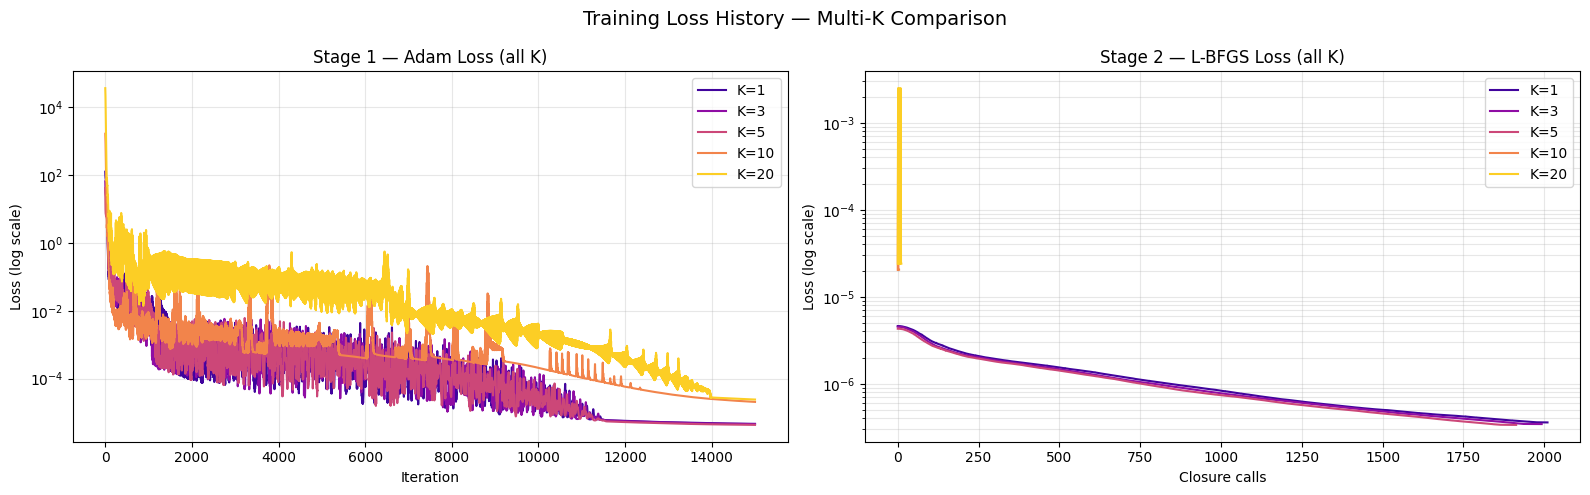

In [8]:
# ── Cell 8: Plot 2 — Loss curves for all K on one figure ─────────────────────

colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(K_VALUES)))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Adam
for color, k_val in zip(colors, K_VALUES):
    h = results[k_val]['adam_hist']['total']
    axes[0].semilogy(h, lw=1.5, color=color, label=f'K={k_val}')
axes[0].set_title('Stage 1 — Adam Loss (all K)', fontsize=12)
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('Loss (log scale)')
axes[0].legend(fontsize=10); axes[0].grid(True, which='both', alpha=0.3)

# L-BFGS
for color, k_val in zip(colors, K_VALUES):
    h = results[k_val]['lbfgs_hist']
    axes[1].semilogy(h, lw=1.5, color=color, label=f'K={k_val}')
axes[1].set_title('Stage 2 — L-BFGS Loss (all K)', fontsize=12)
axes[1].set_xlabel('Closure calls'); axes[1].set_ylabel('Loss (log scale)')
axes[1].legend(fontsize=10); axes[1].grid(True, which='both', alpha=0.3)

fig.suptitle('Training Loss History — Multi-K Comparison', fontsize=14)
plt.tight_layout()
plt.savefig('plot2_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

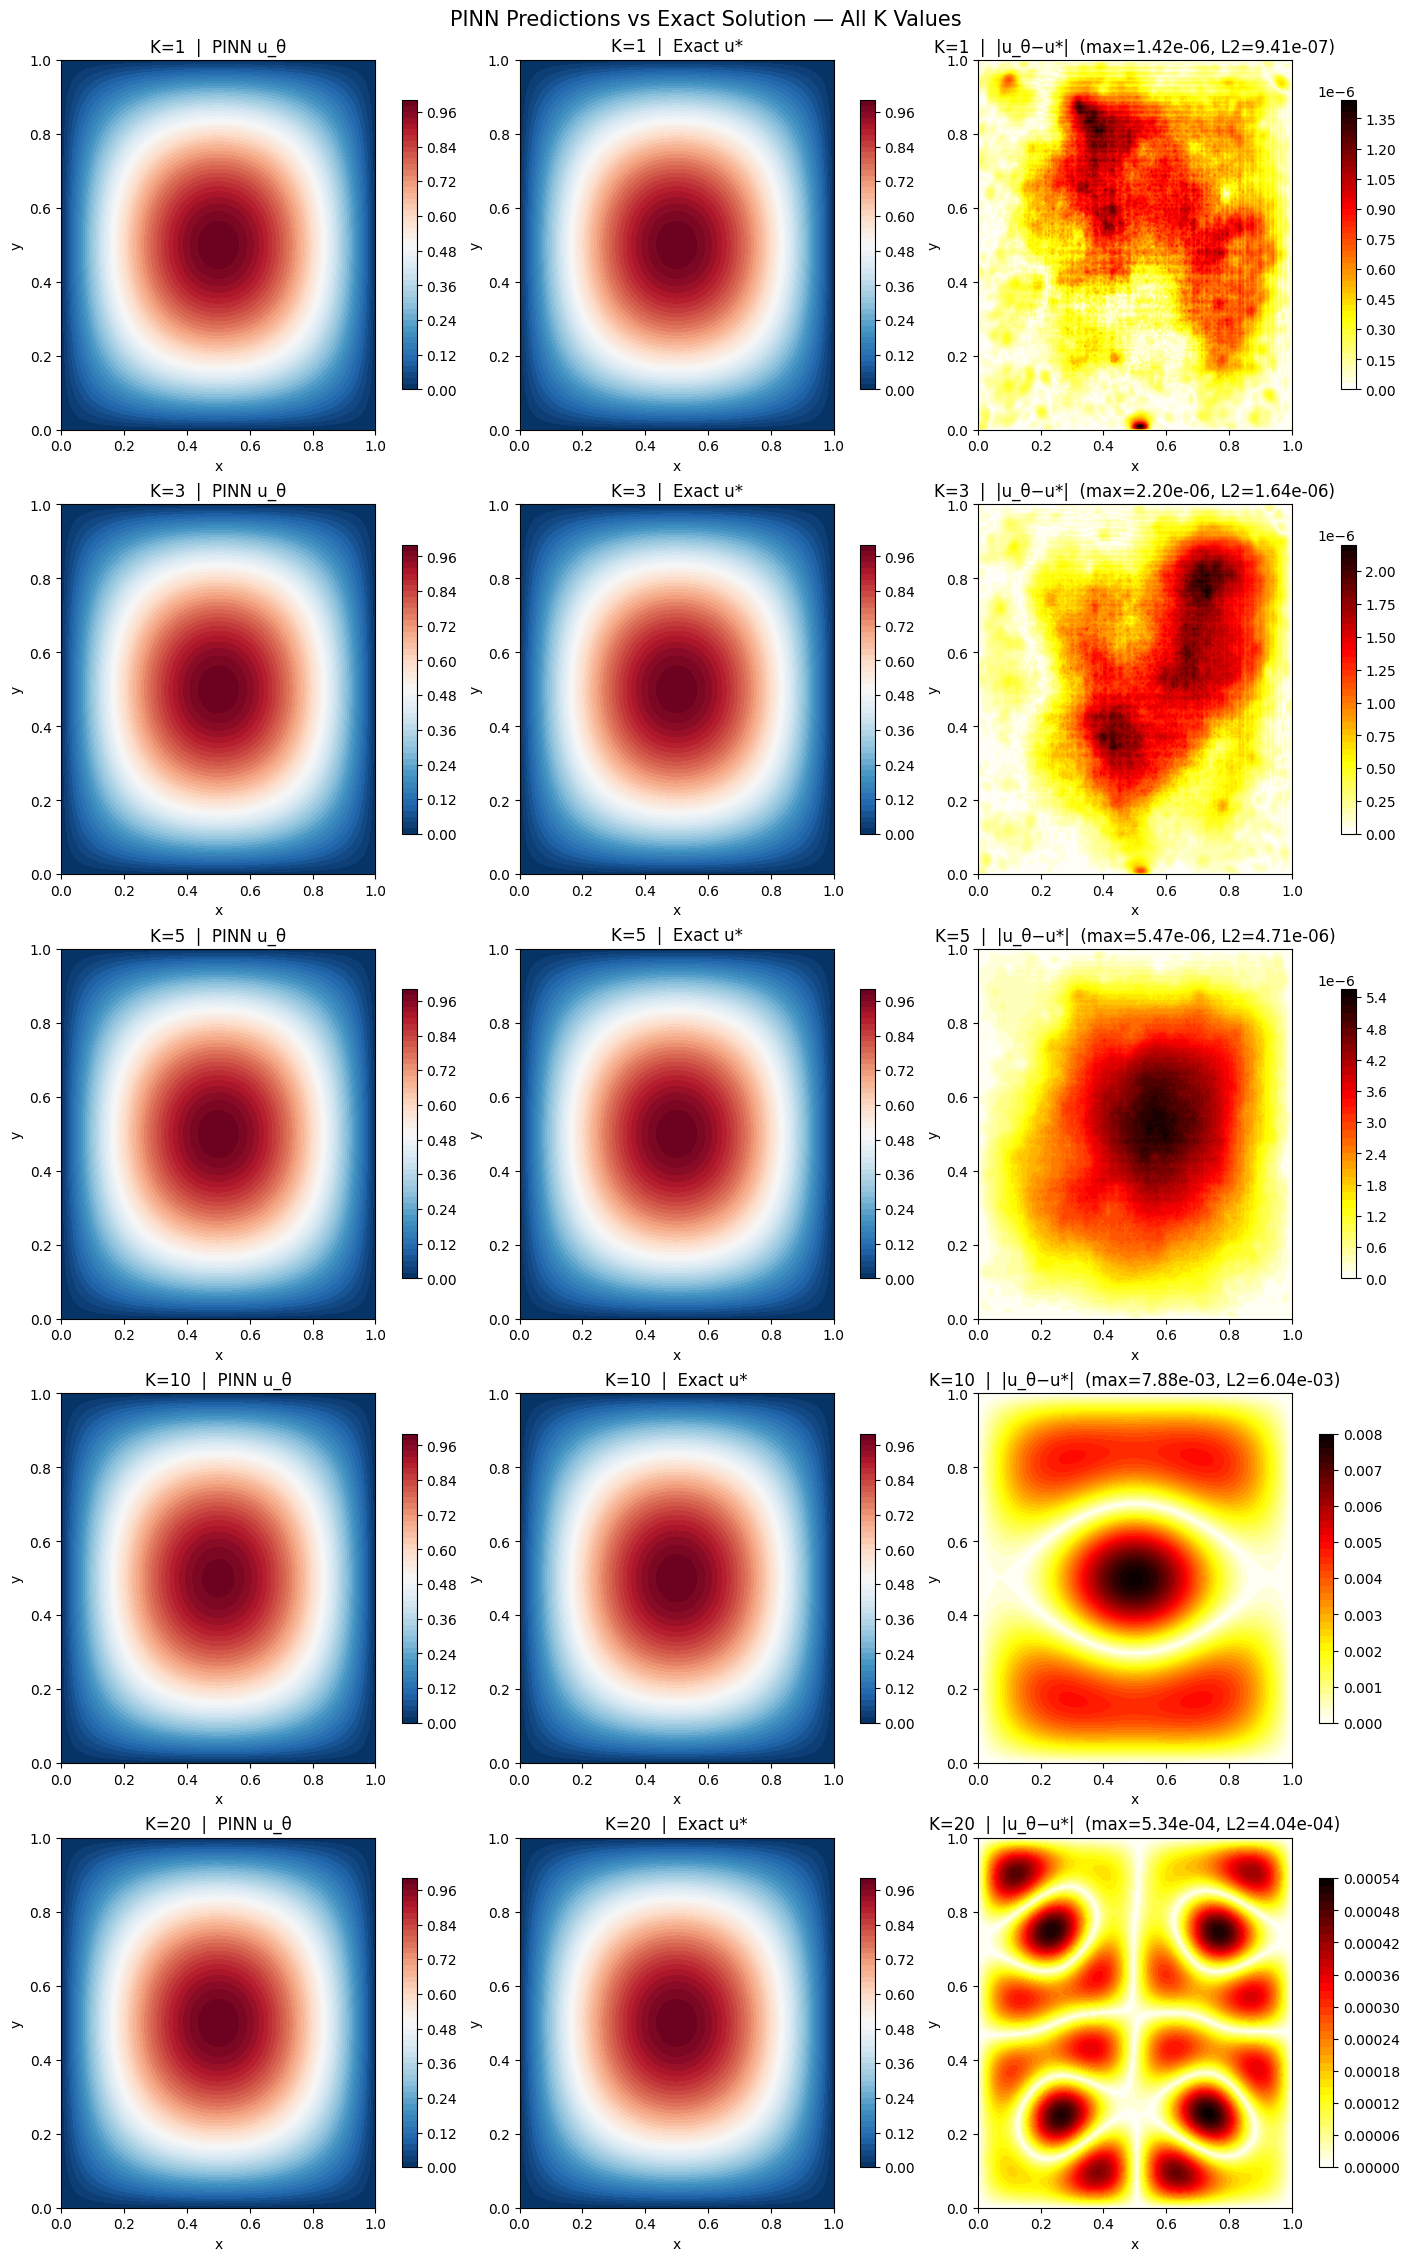

In [9]:
# ── Cell 9: Plot 3 — PINN predictions for each K ─────────────────────────────

fig, axes = plt.subplots(len(K_VALUES), 3,
                         figsize=(14, 4.5*len(K_VALUES)),
                         constrained_layout=True)

vmin_u = U_REF.min()
vmax_u = U_REF.max()

for row, k_val in enumerate(K_VALUES):
    r      = results[k_val]
    U_pred = r['U_pred']
    E_abs  = r['E_abs']

    # Col 0: PINN prediction
    im0 = axes[row, 0].contourf(XX, YY, U_pred, levels=50, cmap='RdBu_r',
                                 vmin=vmin_u, vmax=vmax_u)
    plt.colorbar(im0, ax=axes[row, 0], fraction=0.046)
    axes[row, 0].set_title(f'K={k_val}  |  PINN u_θ')
    axes[row, 0].set_xlabel('x'); axes[row, 0].set_ylabel('y')

    # Col 1: Exact (same for all rows — shown for easy comparison)
    im1 = axes[row, 1].contourf(XX, YY, U_REF, levels=50, cmap='RdBu_r',
                                 vmin=vmin_u, vmax=vmax_u)
    plt.colorbar(im1, ax=axes[row, 1], fraction=0.046)
    axes[row, 1].set_title(f'K={k_val}  |  Exact u*')
    axes[row, 1].set_xlabel('x'); axes[row, 1].set_ylabel('y')

    # Col 2: Absolute error
    im2 = axes[row, 2].contourf(XX, YY, E_abs, levels=50, cmap='hot_r',
                                 vmin=0, vmax=E_abs.max())
    plt.colorbar(im2, ax=axes[row, 2], fraction=0.046)
    axes[row, 2].set_title(
        f'K={k_val}  |  |u_θ−u*|  '
        f'(max={r["l_inf"]:.2e}, L2={r["rel_l2"]:.2e})')
    axes[row, 2].set_xlabel('x'); axes[row, 2].set_ylabel('y')

fig.suptitle('PINN Predictions vs Exact Solution — All K Values', fontsize=15)
plt.savefig('plot3_solution_panels.png', dpi=150, bbox_inches='tight')
plt.show()

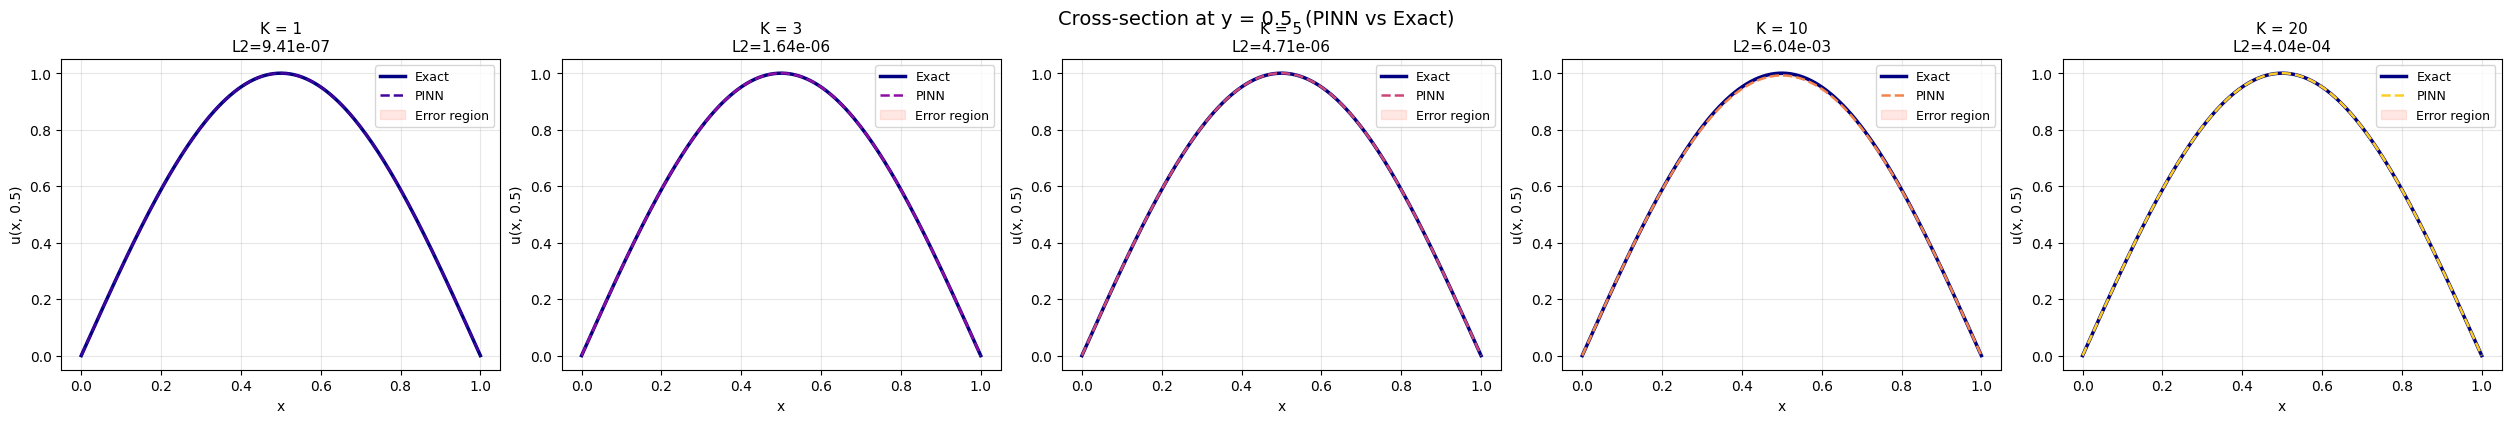

In [10]:
# ── Cell 10: Plot 4 — Cross-section y=0.5 comparison ────────────────────────

fig, axes = plt.subplots(1, len(K_VALUES), figsize=(5*len(K_VALUES), 4),
                         constrained_layout=True)

mid = N_eval // 2   # y = 0.5 row

for ax, (k_val, color) in zip(axes, zip(K_VALUES, colors)):
    r = results[k_val]
    ax.plot(x_e, U_REF[mid],          lw=2.5, color='navy',  label='Exact')
    ax.plot(x_e, r['U_pred'][mid], lw=1.8, ls='--', color=color, label='PINN')
    ax.fill_between(x_e, U_REF[mid], r['U_pred'][mid],
                    alpha=0.15, color='tomato', label='Error region')
    ax.set_title(f'K = {k_val}\nL2={r["rel_l2"]:.2e}', fontsize=11)
    ax.set_xlabel('x'); ax.set_ylabel('u(x, 0.5)')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

fig.suptitle('Cross-section at y = 0.5  (PINN vs Exact)', fontsize=14, y=1.02)
plt.savefig('plot4_crosssection.png', dpi=150, bbox_inches='tight')
plt.show()

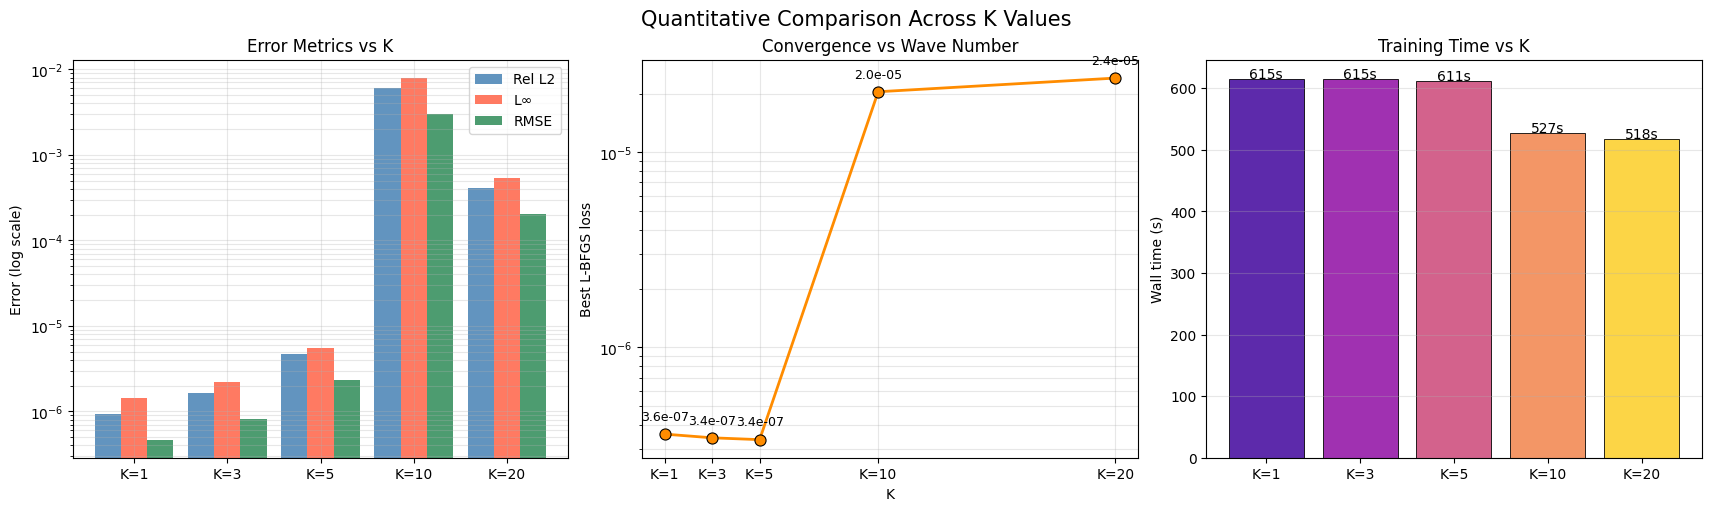

In [11]:
# ── Cell 11: Plot 5 — Error metrics vs K (bar + line charts) ─────────────────

k_arr   = np.array(K_VALUES, dtype=float)
rel_l2s = [results[k]['rel_l2'] for k in K_VALUES]
l_infs  = [results[k]['l_inf']  for k in K_VALUES]
rmses   = [results[k]['rmse']   for k in K_VALUES]
times   = [results[k]['total_time'] for k in K_VALUES]
best_lb = [results[k]['best_lbfgs'] for k in K_VALUES]

fig, axes = plt.subplots(1, 3, figsize=(17, 5), constrained_layout=True)

# ── Error metrics ─────────────────────────────────────────────────────────────
ax = axes[0]
bar_w = 0.28
xs    = np.arange(len(K_VALUES))
ax.bar(xs - bar_w, rel_l2s, width=bar_w, label='Rel L2', color='steelblue', alpha=0.85)
ax.bar(xs,         l_infs,  width=bar_w, label='L∞',     color='tomato',    alpha=0.85)
ax.bar(xs + bar_w, rmses,   width=bar_w, label='RMSE',   color='seagreen',  alpha=0.85)
ax.set_xticks(xs); ax.set_xticklabels([f'K={k}' for k in K_VALUES])
ax.set_yscale('log'); ax.set_ylabel('Error (log scale)')
ax.set_title('Error Metrics vs K', fontsize=12)
ax.legend(); ax.grid(True, which='both', alpha=0.3)

# ── Final loss vs K ───────────────────────────────────────────────────────────
ax = axes[1]
ax.semilogy(K_VALUES, best_lb, 'o-', color='darkorange', lw=2, ms=8,
            markeredgecolor='black', markeredgewidth=0.8)
for k, lb in zip(K_VALUES, best_lb):
    ax.annotate(f'{lb:.1e}', (k, lb), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=9)
ax.set_xlabel('K'); ax.set_ylabel('Best L-BFGS loss')
ax.set_title('Convergence vs Wave Number', fontsize=12)
ax.grid(True, which='both', alpha=0.3)
ax.set_xticks(K_VALUES); ax.set_xticklabels([f'K={k}' for k in K_VALUES])

# ── Training time vs K ────────────────────────────────────────────────────────
ax = axes[2]
ax.bar([f'K={k}' for k in K_VALUES], times, color=colors, alpha=0.85,
       edgecolor='black', linewidth=0.7)
for i, t in enumerate(times):
    ax.text(i, t + 1, f'{t:.0f}s', ha='center', fontsize=10)
ax.set_ylabel('Wall time (s)'); ax.set_title('Training Time vs K', fontsize=12)
ax.grid(axis='y', alpha=0.3)

fig.suptitle('Quantitative Comparison Across K Values', fontsize=15)
plt.savefig('plot5_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

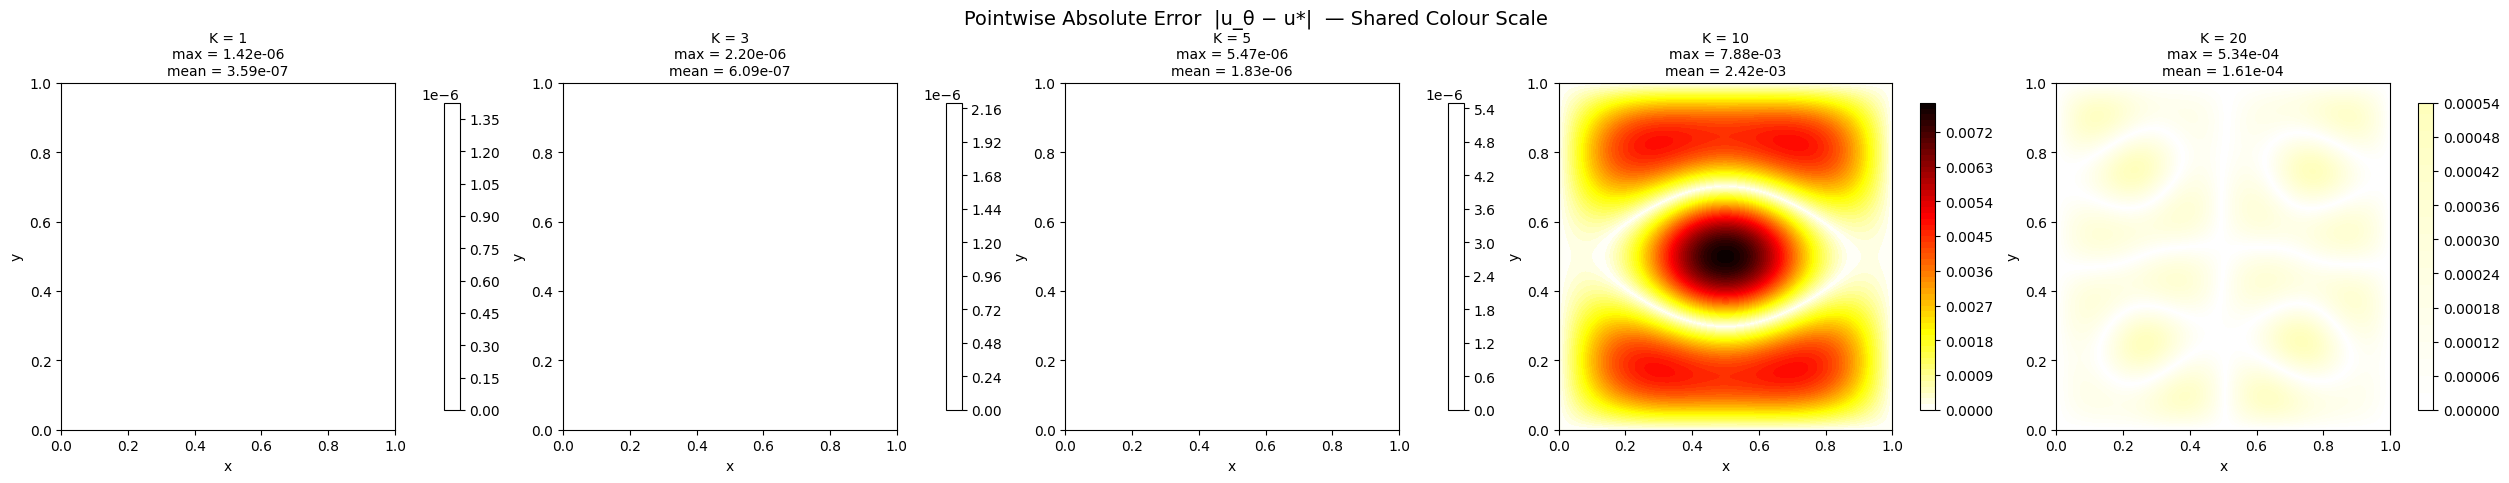

Shared colour scale exposes which K values have worse error regions.


In [12]:
# ── Cell 12: Plot 6 — Pointwise error maps side-by-side ──────────────────────

fig, axes = plt.subplots(1, len(K_VALUES), figsize=(5*len(K_VALUES), 4.5),
                         constrained_layout=True)

# Common colour scale: 0 → max error across all K
global_emax = max(results[k]['E_abs'].max() for k in K_VALUES)

for ax, k_val in zip(axes, K_VALUES):
    r  = results[k_val]
    im = ax.contourf(XX, YY, r['E_abs'], levels=60, cmap='hot_r',
                     vmin=0, vmax=global_emax)
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_title(f'K = {k_val}\n'
                 f'max = {r["l_inf"]:.2e}\n'
                 f'mean = {r["E_abs"].mean():.2e}', fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('y')

fig.suptitle('Pointwise Absolute Error  |u_θ − u*|  — Shared Colour Scale',
             fontsize=14, y=1.04)
plt.savefig('plot6_error_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print("Shared colour scale exposes which K values have worse error regions.")

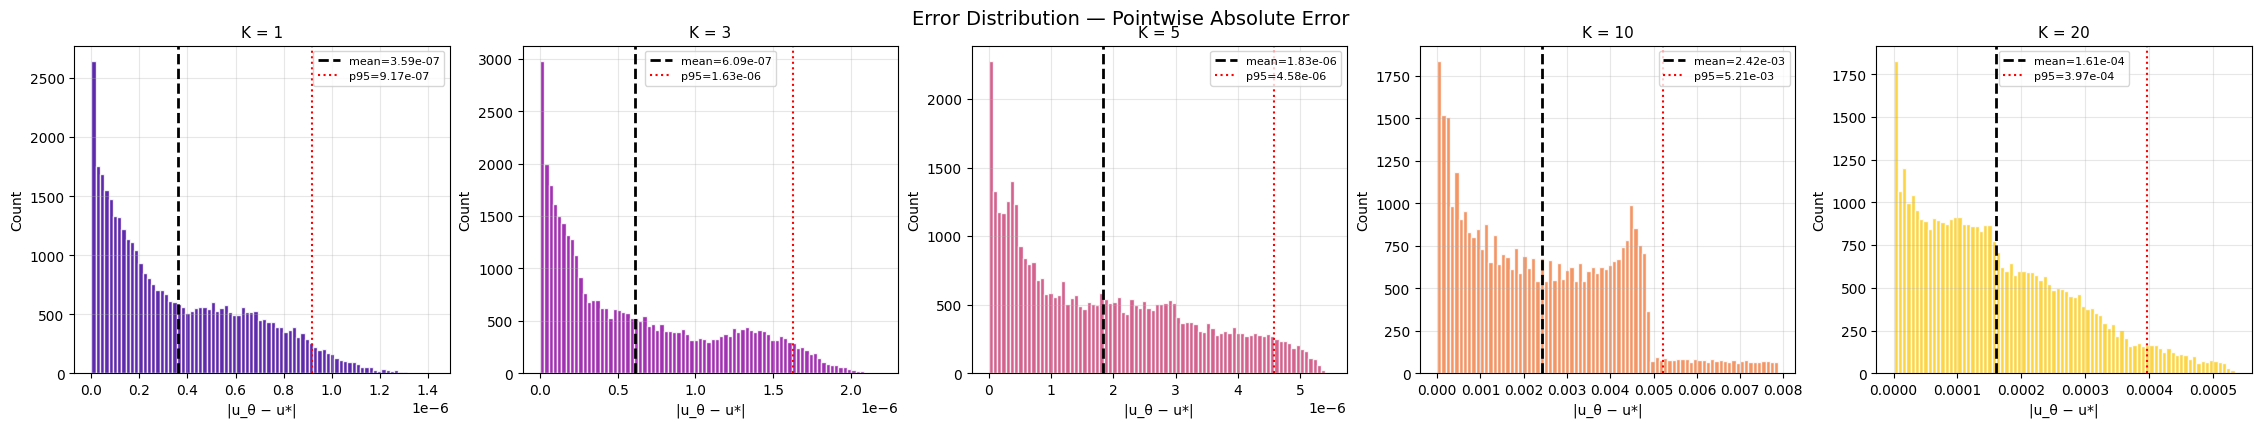

In [ ]:
# ── Cell 13: Plot 7 — Error histograms ───────────────────────────────────────

fig, axes = plt.subplots(1, len(K_VALUES), figsize=(4.5*len(K_VALUES), 4),
                         constrained_layout=True)

for ax, (k_val, color) in zip(axes, zip(K_VALUES, colors)):
    r = results[k_val]
    e = r['E_abs'].ravel()
    ax.hist(e, bins=80, color=color, edgecolor='white', lw=0.3, alpha=0.85)
    ax.axvline(e.mean(), color='black', lw=2, ls='--',
               label=f'mean={e.mean():.2e}')
    ax.axvline(np.percentile(e, 95), color='red', lw=1.5, ls=':',
               label=f'p95={np.percentile(e,95):.2e}')
    ax.set_title(f'K = {k_val}', fontsize=11)
    ax.set_xlabel('|u_θ − u*|'); ax.set_ylabel('Count')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig.suptitle('Error Distribution Pointwise Absolute Error', fontsize=14, y=1.03)
plt.savefig('plot7_error_histograms.png', dpi=150, bbox_inches='tight')
plt.show()